# Machine Learning Modeling & Forecasting
**Overview:** This notebook focuses on building and optimizing the predictive engine for our forecasting task. We will utilize `XGBoost` combined with `Optuna` for hyperparameter tuning. Due to the time-series nature of the data, we will implement Time Series Cross-Validation and a sequential prediction strategy (incorporating blending with historical data) to forecast future revenue and COGS.

## 1. Setup & Data Loading
In this section, we initialize our analytical environment, import required libraries, and ingest the pre-cleaned datasets for downstream processing.

### 1.1. Import Libraries & Environment Setup

In [17]:
import warnings
# Ignore warning messages for cleaner notebook output
warnings.filterwarnings('ignore')

import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from xgboost import plot_importance
from sklearn.model_selection import TimeSeriesSplit, cross_validate

### 1.2. Load Datasets
Loading the cleaned `.parquet` files from the processed dataset directory.

In [18]:
DATA_PATH = '../dataset/04_after_fe/'
print("Loading data...")

df_daily = pd.read_parquet(DATA_PATH + 'processed_data_daily.parquet')

print("Load data successfully")

Loading data...
Load data successfully


## 2. Helper Functions
To facilitate sequential forecasting later, we need a function to dynamically generate promotion and event features for any given future date based on our business calendar rules.

In [19]:
def get_promo_features_for_single_date(current_date):
    year = current_date.year
    month_day = current_date.strftime('%m-%d')
    
    is_spring = 1 if '03-18' <= month_day <= '04-17' else 0
    is_midyear = 1 if '06-23' <= month_day <= '07-22' else 0
    is_fall = 1 if (('08-30' <= month_day <= '10-01') or 
                    ((year % 4 == 1) and month_day == '10-02')) else 0
    is_yearend = 1 if (('11-18' <= month_day <= '12-31') or 
                       ('01-01' <= month_day <= '01-02')) else 0
    is_rural = 1 if ((year % 2 == 1) and ('01-30' <= month_day <= '03-01')) else 0
    is_urban = 1 if ((year % 2 == 1) and ('07-30' <= month_day <= '09-02')) else 0
    
    return {
        'is_any_promotion': 1 if (is_spring or is_midyear or is_fall or 
                                  is_yearend or is_rural or is_urban) else 0,
        'num_active_promos': is_spring + is_midyear + is_fall + is_yearend + is_rural + is_urban,
        'is_major_sale': 1 if (is_spring or is_midyear or is_yearend) else 0,
        'is_minor_sale': 1 if (is_fall or is_rural or is_urban) else 0,
        'chanel_promotion': (
            4 if (is_spring or is_fall) else
            1 if is_rural else
            2 if is_urban else
            3 if is_midyear else
            0 if is_yearend else
            -1
        )
    }

def objective(trial):
    # 1. Khai báo các "nút vặn" cần tìm
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }

    # 2. Chạy thử mô hình với bộ tham số này
    model = XGBRegressor(**param, tree_method='hist', random_state=42) # Dùng hist để chạy cho nhanh
    model.fit(X_train, y_train)
    
    # 3. Tính sai số trên tập Validation (Nhớ dùng Time Series Split để test cho chuẩn)
    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    rmse = np.sqrt(mse)
    
    return rmse

## 3. Feature Selection & Train/Validation Split
We explicitly define the features the model will use to learn. We then split our dataset chronologically, using data prior to November 2022 for training, and the remaining for validation. This strict temporal split prevents data leakage.

In [20]:
final_features=['seg_Balanced', 'seg_Activewear', 'seg_Premium', 'seg_All-weather', 'seg_Everyday', 'seg_Performance', 
                'cat_Casual', 'cat_Outdoor', 'cat_Streetwear', 
                
                'rev_lag_1', 'rev_lag_7', 'rev_lag_365', 'profit_lag_7', 'profit_lag_365', 
                'margin_rate_lag_7', 'margin_rate_lag_365', 
                
                'month', 
                'avg_discount_pct', 'max_discount_pct',

                'is_any_promotion', 'num_active_promos', 'is_major_sale', 'is_minor_sale', 'chanel_promotion']

In [21]:
# 1. Define Target
target = 'Revenue'

# 2. Chronological Data Split (e.g., extracting the last 2 months of 2022 for testing)
train_data = df_daily[df_daily['Date'] < '2022-11-01']
val_data = df_daily[df_daily['Date'] >= '2022-11-01']

# 3. Create X (Features) and y (Target) sets
X_train = train_data[final_features]
y_train = train_data[target]

X_val = val_data[final_features]
y_val = val_data[target]

print(f"Ready! Train shape: {X_train.shape}, Val shape: {X_val.shape}")

Ready! Train shape: (3772, 24), Val shape: (61, 24)


## 4. Hyperparameter Tuning with Optuna
To maximize the performance of our XGBoost model, we use Optuna to search for the optimal set of hyperparameters. We define an objective function that evaluates the model's Root Mean Squared Error (RMSE) on the validation set for different parameter combinations.

In [22]:
# 4. Bắt đầu cuộc đi tìm "kho báu"
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=50) 

print("Best parameters found:", study.best_params)

[I 2026-04-29 19:22:30,729] A new study created in memory with name: no-name-4df53a54-d0aa-4afd-8500-9308cf2af0b3
[I 2026-04-29 19:22:37,283] Trial 0 finished with value: 251073.01274090662 and parameters: {'n_estimators': 1062, 'max_depth': 10, 'learning_rate': 0.05395030966670229, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'reg_alpha': 0.004207053950287938, 'reg_lambda': 0.0017073967431528124}. Best is trial 0 with value: 251073.01274090662.
[I 2026-04-29 19:22:42,984] Trial 1 finished with value: 251866.38478382208 and parameters: {'n_estimators': 1800, 'max_depth': 7, 'learning_rate': 0.051059032093947576, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'reg_alpha': 2.1368329072358767, 'reg_lambda': 0.0070689749506246055}. Best is trial 0 with value: 251073.01274090662.
[I 2026-04-29 19:22:43,861] Trial 2 finished with value: 230853.75048550928 and parameters: {'n_estimators': 772, 'max_depth': 4, 'learning_rate': 0.02014847788

Best parameters found: {'n_estimators': 722, 'max_depth': 4, 'learning_rate': 0.011820251886267157, 'subsample': 0.5226526919821477, 'colsample_bytree': 0.5020346162094567, 'reg_alpha': 0.008289435299830951, 'reg_lambda': 0.0010660133550785748}


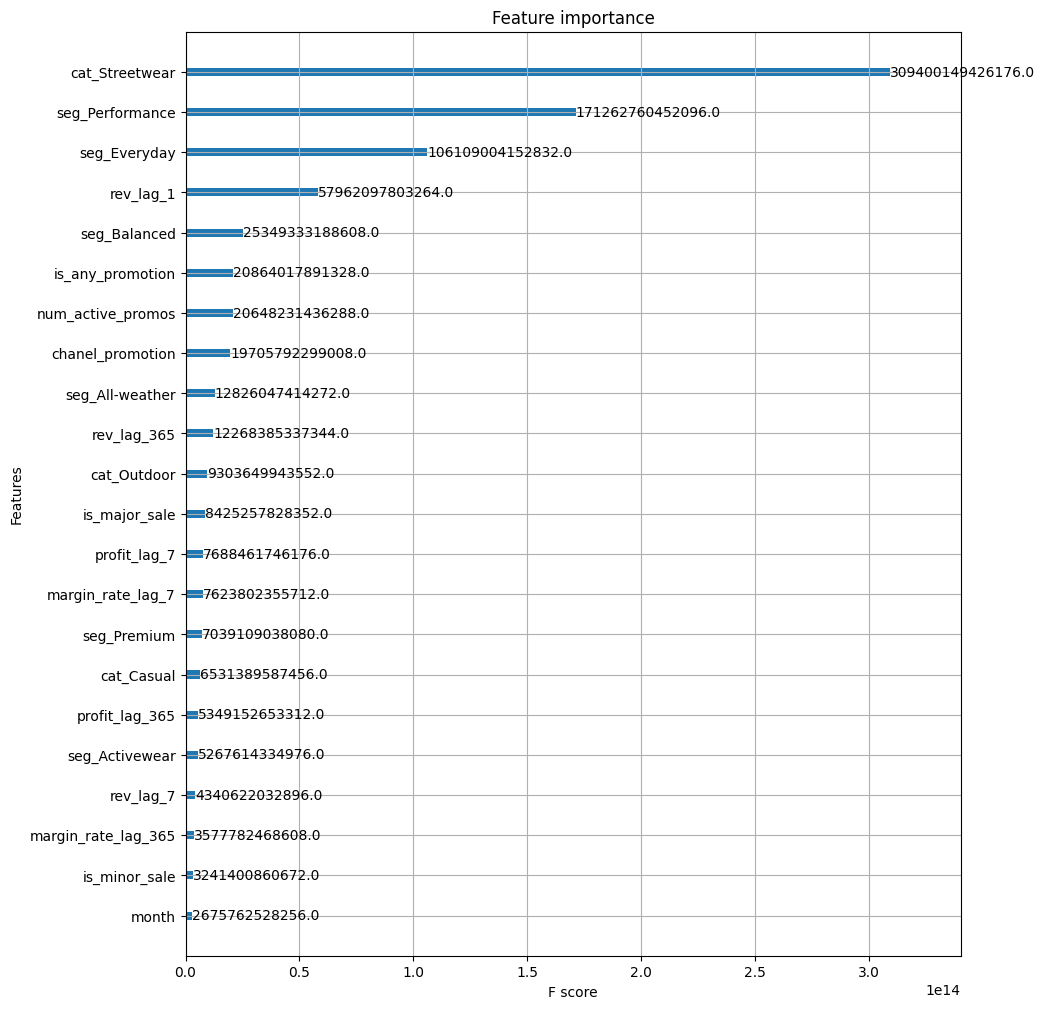

In [23]:
# 1. Train lại một model với bộ tham số xịn nhất Optuna vừa tìm được
best_model = XGBRegressor(**study.best_params)
best_model.fit(X_train, y_train)

# 2. Vẽ biểu đồ quan trọng theo GÁNH (Gain) - Cái này chuẩn hơn Weight
fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(best_model, importance_type='gain', ax=ax)
plt.show()

## 5. Final Model Training (Revenue & COGS)
Based on the Optuna study results, we declare the best parameters found. We will use this optimal configuration to train two separate XGBoost models: one for forecasting Revenue and another for forecasting Cost of Goods Sold (COGS).

In [24]:
# Declare best_param based on previous Optuna results
best_param={
    'n_estimators': 1176,
    'max_depth': 3, 
    'learning_rate': 0.018056241009889947, 
    'subsample': 0.5948675344658239, 
    'colsample_bytree': 0.697160751129319, 
    'reg_alpha': 2.871945120684227, 
    'reg_lambda': 1.4150272643228525
}

# Train Revenue Model
model_rev = XGBRegressor(**best_param, random_state=42)
model_rev.fit(df_daily[final_features], df_daily['Revenue'])

# Train COGS Model
model_cogs= XGBRegressor(**best_param, random_state=42)
model_cogs.fit(df_daily[final_features], df_daily['COGS'])

print("Successfully trained the dual 'brain' models (Revenue & COGS)!")

Successfully trained the dual 'brain' models (Revenue & COGS)!


## 6. Model Evaluation (Time Series Cross-Validation)
Since this is time-series data, standard randomized cross-validation is invalid. We use `TimeSeriesSplit` to evaluate our models sequentially, ensuring future data is never used to predict the past.

In [25]:
tscv = TimeSeriesSplit(n_splits=5)
scoring = {'mse': 'neg_mean_squared_error', 'r2': 'r2'}
# EVALUATE REVENUE MODEL
cv_rev = cross_validate(model_rev, df_daily[final_features], df_daily['Revenue'], 
                         cv=tscv, scoring=scoring)

# EVALUATE COGS MODEL
cv_cogs = cross_validate(model_cogs, df_daily[final_features], df_daily['COGS'], 
                          cv=tscv, scoring=scoring)

# SUMMARY OF RESULTS
print(f"[REVENUE] Local RMSE: {np.sqrt(-cv_rev['test_mse'].mean()):,.2f} | R²: {cv_rev['test_r2'].mean():.4f}")
print(f"[COGS]    Local RMSE: {np.sqrt(-cv_cogs['test_mse'].mean()):,.2f} | R²: {cv_cogs['test_r2'].mean():.4f}")

[REVENUE] Local RMSE: 499,779.35 | R²: 0.9583
[COGS]    Local RMSE: 346,461.13 | R²: 0.9674


### 6.1. Feature Importance Analysis
Visualizing the most influential features driving the model's predictions. We analyze the 'weight' (frequency of a feature being used to split data across all trees) to understand which variables provide the most consistent signal.

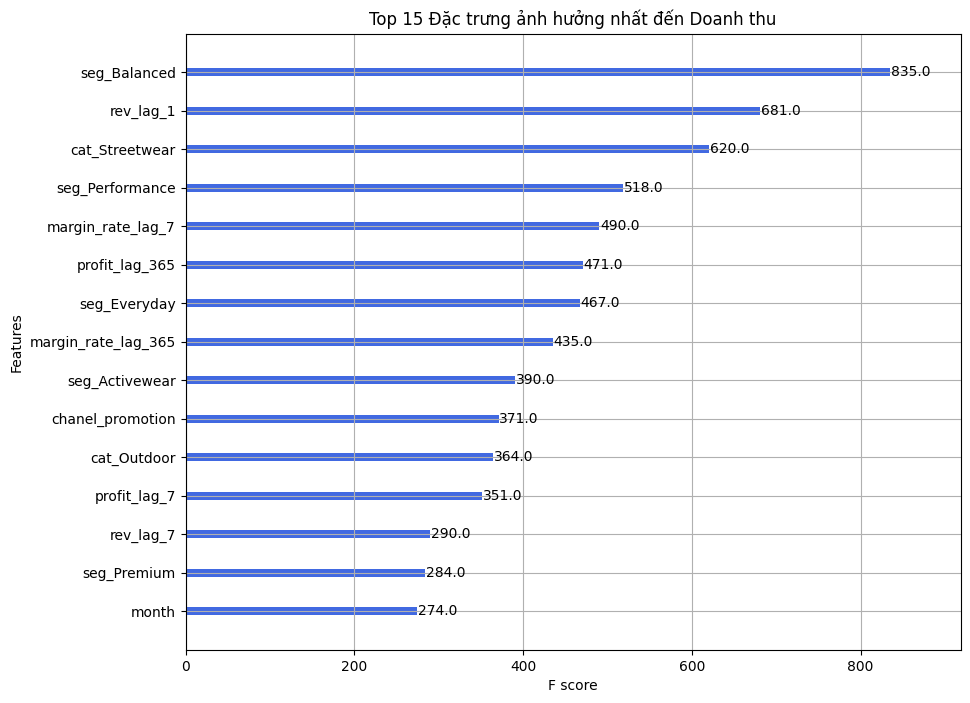

In [26]:
# 1. Set plot size
fig, ax = plt.subplots(figsize=(10, 8))

# 2. Plot feature importance (Using 'weight' to see the frequency of splits)
plot_importance(model_rev, ax=ax, max_num_features=15, importance_type='weight', color='royalblue')

plt.title("Top 15 Đặc trưng ảnh hưởng nhất đến Doanh thu")
plt.show()

## 7. Advanced Forecasting Strategy
To handle potential missing dates in historical data, we create a safe lag retrieval function. It attempts to find the exact lag date, but if missing, it falls back to the closest available date within a 3-day window.

In [27]:
ALL_DATES = sorted(df_daily['Date'].unique())

def get_lag_safe(date_obj, lag_days, key, hist_dict):
    target_date = date_obj - pd.Timedelta(days=lag_days)
    
    if target_date in hist_dict:
        return hist_dict[target_date].get(key, 0)
    
    valid_dates = [d for d in ALL_DATES if d <= target_date]
    if valid_dates:
        closest_date = valid_dates[-1]
        if abs((closest_date - target_date).days) <= 3:
            return hist_dict.get(closest_date, {}).get(key, 0)
    return 0

### 7.1. Blending Ratio Optimization
We establish a validation set (Year 2022) to simulate sequential forecasting. In this phase, we dynamically blend the AI's prediction with historical year-over-year performance (Lag 365) to create a more stable forecast. We run a grid search to find the optimal growth factor and history-to-AI weighting ratio.

In [28]:
# Create validation set (Year 2022)
val_start = '2022-01-01'
val_end = '2022-12-31'

# Extract the remaining training days to use as history for validation
historical_val = df_daily[df_daily['Date'] < val_start][['Date', 'Revenue', 'Profit', 'avg_discount_pct', 'max_discount_pct']].copy()
historical_val = historical_val.rename(columns={'Date': 'ds', 'Revenue': 'y', 'Profit': 'profit'})
historical_val_dict = historical_val.set_index('ds').to_dict('index')

# Create static monthly averages for categorical features
train_monthly_avg = df_daily.groupby('month')[
    ['seg_Balanced', 'seg_Activewear', 'seg_Premium', 'seg_All-weather', 'seg_Everyday', 'seg_Performance', 
    'cat_Casual', 'cat_Outdoor', 'cat_Streetwear']
].mean().to_dict('index')

# Initialize variables to find optimal blending ratio
best_score = float('inf')
best_ratio = 0.5
best_growth = 1.00

print("Đang tìm tỷ lệ blending tối ưu...")
# Grid Search for Growth Factor and Historical Weight Ratio
for growth in [0.96, 0.97, 0.98, 0.99, 1.0, 1.01, 1.02, 1.03, 1.04, 1.05]:
    for ratio in [0.45, 0.5, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
        val_results = []
        temp_dict = historical_val_dict.copy()
        
        for current_date in pd.date_range(start=val_start, end=val_end):
            month = current_date.month
            promo = get_promo_features_for_single_date(current_date)
            # Construct feature dictionary for the current target date
            current_features = {
                'month': month,
                'day_of_week': current_date.dayofweek,
                'is_weekend': 1 if current_date.dayofweek >= 5 else 0,
                'rev_lag_1': get_lag_safe(current_date, 1, 'y', temp_dict),
                'rev_lag_7': get_lag_safe(current_date, 7, 'y', temp_dict),
                'rev_lag_365': get_lag_safe(current_date, 365, 'y', temp_dict),
                'profit_lag_7': get_lag_safe(current_date, 7, 'profit', temp_dict),
                'profit_lag_365': get_lag_safe(current_date, 365, 'profit', temp_dict),
                'avg_discount_pct': get_lag_safe(current_date, 365, 'avg_discount_pct', temp_dict),
                'max_discount_pct': get_lag_safe(current_date, 365, 'max_discount_pct', temp_dict),

                'is_any_promotion': promo['is_any_promotion'],
                'num_active_promos': promo['num_active_promos'],
                'is_major_sale': promo['is_major_sale'],
                'is_minor_sale': promo['is_minor_sale'],
                'chanel_promotion': promo['chanel_promotion']
            }
            # Calculate dynamic margin rates
            rev_lag_7 = get_lag_safe(current_date, 7, 'y', temp_dict)
            profit_lag_7_val = current_features['profit_lag_7']
            current_features['margin_rate_lag_7'] = profit_lag_7_val / (rev_lag_7 + 1)

            rev_lag_365 = get_lag_safe(current_date, 365, 'y', temp_dict)
            profit_lag_365_val = current_features['profit_lag_365']
            current_features['margin_rate_lag_365'] = profit_lag_365_val / (rev_lag_365 + 1)

            # Add static monthly features
            for k, v in train_monthly_avg.get(month, {}).items():
                current_features[k] = v
            
            # Model Predictions
            X_pred = pd.DataFrame([current_features])[final_features]
            revenue_pred = model_rev.predict(X_pred)[0]
            cogs_pred = model_cogs.predict(X_pred)[0]
            
            # Retrieve historical baselines for blending
            hist_rev = get_lag_safe(current_date, 365, 'y', temp_dict)
            hist_cogs = hist_rev - get_lag_safe(current_date, 365, 'profit', temp_dict) if hist_rev > 0 else 0
            
            # Final Blended Prediction = (History * Growth * Weight) + (AI * Weight)
            final_rev = (hist_rev * growth * ratio) + (revenue_pred * (1 - ratio))
            final_cogs = (hist_cogs * growth * ratio) + (cogs_pred * (1 - ratio))
            
            # Update dictionary for autoregressive feeding (next day's prediction)
            temp_dict[current_date] = {'y': final_rev, 'profit': final_rev - final_cogs, 'avg_discount_pct': current_features['avg_discount_pct'], 
                'max_discount_pct': current_features['max_discount_pct']}
            val_results.append({'Date': current_date, 'Revenue': final_rev, 'COGS': final_cogs})
        
        # Evaluation
        val_df = pd.DataFrame(val_results)
        actual_train = df_daily[df_daily['Date'].between(val_start, val_end)]
        val_merged = val_df.merge(actual_train[['Date', 'Revenue', 'COGS']], on='Date', suffixes=('_pred', '_actual'))
        
        mse_rev = mean_squared_error(val_merged['Revenue_actual'], val_merged['Revenue_pred'])
        mse_cogs = mean_squared_error(val_merged['COGS_actual'], val_merged['COGS_pred'])
        total_mse = mse_rev + mse_cogs
        
        # Keep track of the best performing ratio
        if total_mse < best_score:
            best_score = total_mse
            best_ratio = ratio
            best_growth = growth

print(f"\nOPTIMAL BLENDING RATIO:")
print(f"   - History weight: {best_ratio:.0%}")
print(f"   - AI weight:      {1-best_ratio:.0%}")
print(f"   - Growth factor:  {best_growth}")
print(f"   - Best MSE:       {best_score:,.2f}")

Đang tìm tỷ lệ blending tối ưu...


KeyboardInterrupt: 

## 8. Final Sequential Prediction (2023 - 2024)

Armed with our trained dual-models and optimized blending strategy, we now generate the final forecasts. Because future lag features depend on future predictions, we must iterate day-by-day. Each day's predicted Revenue and Profit becomes the "historical" data for forecasting the dates that follow (Autoregressive approach).

In [ ]:
print("Starting sequential forecasting process...")

# Initialize the historical anchor
start_pred_date = pd.to_datetime('2023-01-01')
# Create historical data up to the prediction start date
historical_df = df_daily[df_daily['Date'] < start_pred_date][['Date', 'Revenue', 'Profit', 'avg_discount_pct', 'max_discount_pct']].copy()
historical_df = historical_df.rename(columns={'Date': 'ds', 'Revenue': 'y', 'Profit': 'profit'})
historical_dict = historical_df.set_index('ds').to_dict('index')
# Define future prediction range
future_dates = pd.date_range(start='2023-01-01', end='2024-07-01')
results = []

# Static features (doesn't change over time, using monthly average)
train_monthly_avg = df_daily.groupby('month')[
    ['seg_Balanced', 'seg_Activewear', 'seg_Premium', 'seg_All-weather', 'seg_Everyday', 'seg_Performance', 
    'cat_Casual', 'cat_Outdoor', 'cat_Streetwear']
].mean().to_dict('index')

start_pred_date = pd.to_datetime('2023-01-01')
total_pred_days = 547
# Sequential Prediction Loop
for current_date in tqdm(future_dates, desc="Predicting"):
    month = current_date.month
    promo = get_promo_features_for_single_date(current_date)
    # Create features for the current day
    current_features = {
        'month': month,
        'day_of_week': current_date.dayofweek,
        'is_weekend': 1 if current_date.dayofweek >= 5 else 0,
        'profit_lag_365': get_lag_safe(current_date, 365, 'profit', historical_dict),
        'rev_lag_1': get_lag_safe(current_date, 1, 'y', historical_dict),
        'rev_lag_7': get_lag_safe(current_date, 7, 'y', historical_dict),
        'rev_lag_365': get_lag_safe(current_date, 365, 'y', historical_dict),
        'profit_lag_7': get_lag_safe(current_date, 7, 'profit', historical_dict),
        'margin_rate_lag_7': get_lag_safe(current_date, 7, 'profit', historical_dict) / (get_lag_safe(current_date, 7, 'y', historical_dict) + 1),
        'margin_rate_lag_365': get_lag_safe(current_date, 365, 'profit', historical_dict) / (get_lag_safe(current_date, 365, 'y', historical_dict) + 1),
        'avg_discount_pct': get_lag_safe(current_date, 365, 'avg_discount_pct', historical_dict),
        'max_discount_pct': get_lag_safe(current_date, 365, 'max_discount_pct', historical_dict),

        'is_any_promotion': promo['is_any_promotion'],
        'num_active_promos': promo['num_active_promos'],
        'is_major_sale': promo['is_major_sale'],
        'is_minor_sale': promo['is_minor_sale'],
        'chanel_promotion': promo['chanel_promotion']
    }
    # Add static features from monthly average data
    for k, v in train_monthly_avg.get(month, {}).items():
        current_features[k] = v

    # Predict Revenue and COGS
    X_pred = pd.DataFrame([current_features])[final_features]
    revenue_pred = model_rev.predict(X_pred)[0]
    cogs_pred = model_cogs.predict(X_pred)[0]

    # Blending with History
    hist_rev = get_lag_safe(current_date, 365, 'y', historical_dict)
    hist_cogs = hist_rev - get_lag_safe(current_date, 365, 'profit', historical_dict) if hist_rev > 0 else 0
    # Business blending rules
    growth_factor = 1.15
    hist_weight=0.7
    ai_weight=0.3
    # Final Blended Prediction formula
    final_rev = (hist_rev * growth_factor * hist_weight) + (revenue_pred * ai_weight)
    final_cogs = (hist_cogs * growth_factor * hist_weight) + (cogs_pred * ai_weight)
    # Update historical_dict for subsequent predictions
    historical_dict[current_date] = {'y': final_rev, 'profit': final_rev - final_cogs, 
        'avg_discount_pct': current_features['avg_discount_pct'], 'max_discount_pct': current_features['max_discount_pct']}
    
    # Save daily result
    results.append({
        'Date': current_date.strftime('%Y-%m-%d'),
        'Revenue': final_rev,
        'COGS': final_cogs
    })

Bắt đầu quá trình dự đoán tuần tự...


Đang dự đoán: 100%|██████████| 548/548 [00:05<00:00, 104.22it/s]


## 9. Submission Export
Construct the final DataFrame and export it to a `.csv` file formatted properly for submission.

In [ ]:
EXPORT_PATH = '../dataset/05_submission/'
os.makedirs(EXPORT_PATH, exist_ok=True)

# Tạo và lưu file submission
submission_final = pd.DataFrame(results)

# Review dataset schemas and non-null counts
submission_final.info()

# Export the processed dataframes
submission_final.to_csv(EXPORT_PATH + 'final_submission.csv', index=False)

print(f"✅ File 'final_submission.csv' is successfully generated and ready for submission.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     548 non-null    object 
 1   Revenue  548 non-null    float32
 2   COGS     548 non-null    float32
dtypes: float32(2), object(1)
memory usage: 8.7+ KB
✅ File 'final_submission.csv' đã sẵn sàng nộp.
